# eda.ipynb -- Checkpoint 3: Exploratory Analysis

CS 418 football project. One shared notebook for all six parts of
checkpoint 3. Research questions:
- Is rushing or passing more effective in winning NFL games?
- Do the stats suggest punting or going for it on 4th down?
- How much does average WR separation correlate with receiving yardage?

**Sections below:**
1. Dataset profiling (primary datasets) -- John
2. Anomalies -- John
3. Distributions -- Antonio
4. Relationships -- TODO: assign
5. So what? -- TODO: assign
6. What next? + revised research questions -- TODO: assign

Loading matches the scope already established in `data_acquisition.ipynb`
(playbyplay: 2025; player_stats: 2021-2025).

In [1]:
import polars as pl
import nflreadpy as nfl

Loading Seaborn, numpy, matplotlib for plotting purposes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import seaborn as sns

# Part 1: Dataset Profiling

## Profile: `playbyplay`

In [3]:
playbyplay = nfl.load_pbp(2025)
playbyplay.shape

(48771, 372)

In [4]:
playbyplay.glimpse(max_items_per_column=5)

Rows: 48771
Columns: 372
$ play_id                              <f64> 1.0, 40.0, 63.0, 85.0, 115.0
$ game_id                              <str> '2025_01_ARI_NO', '2025_01_ARI_NO', '2025_01_ARI_NO', '2025_01_ARI_NO', '2025_01_ARI_NO'
$ old_game_id                          <str> '2025090705', '2025090705', '2025090705', '2025090705', '2025090705'
$ home_team                            <str> 'NO', 'NO', 'NO', 'NO', 'NO'
$ away_team                            <str> 'ARI', 'ARI', 'ARI', 'ARI', 'ARI'
$ season_type                          <str> 'REG', 'REG', 'REG', 'REG', 'REG'
$ week                                 <i32> 1, 1, 1, 1, 1
$ posteam                              <str> null, 'ARI', 'ARI', 'ARI', 'ARI'
$ posteam_type                         <str> null, 'away', 'away', 'away', 'away'
$ defteam                              <str> null, 'NO', 'NO', 'NO', 'NO'
$ side_of_field                        <str> null, 'NO', 'ARI', 'ARI', 'ARI'
$ yardline_100                         <f64> null, 

In [5]:
playbyplay.null_count()

play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,…,home_coach,away_coach,stadium_id,game_stadium,aborted_play,success,passer,passer_jersey_number,rusher,rusher_jersey_number,receiver,receiver_jersey_number,pass,rush,first_down,special,play,passer_id,rusher_id,receiver_id,name,jersey_number,id,fantasy_player_name,fantasy_player_id,fantasy,fantasy_id,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,2729,2727,2729,3585,3548,0,4,4,4,0,0,572,0,0,7993,0,4,354,0,572,0,1445,1511,0,0,1445,0,0,0,30483,…,0,0,0,0,0,570,26705,26702,34235,33473,30233,30058,0,0,1511,0,0,26705,34235,30233,12169,12626,12169,15842,15842,14480,14480,0,0,570,32447,32447,32447,32447,32447,11707,12752


In [6]:
# Key columns for the rush-vs-pass question, including the notable columns
# called out in README.md (posteam, yards_gained, success, passer, rusher, receiver).
pbp_key_cols = [
    "play_type", "yards_gained", "epa", "success", "down", "ydstogo",
    "yardline_100", "qtr", "posteam", "defteam", "game_id",
    "passer", "rusher", "receiver"
]
playbyplay.select(pbp_key_cols).describe()

statistic,play_type,yards_gained,epa,success,down,ydstogo,yardline_100,qtr,posteam,defteam,game_id,passer,rusher,receiver
str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str
"""count""","""47326""",47260.0,48201.0,48201.0,40778.0,48771.0,45223.0,48771.0,"""46042""","""46042""","""48771""","""22066""","""14536""","""18538"""
"""null_count""","""1445""",1511.0,570.0,570.0,7993.0,0.0,3548.0,0.0,"""2729""","""2729""","""0""","""26705""","""34235""","""30233"""
"""mean""",null,3.944879,0.013139,0.445779,2.007651,7.046011,47.139089,2.574235,null,null,null,null,null,null
"""std""",null,7.601325,1.258957,0.497057,1.006315,4.866811,23.757689,1.132769,null,null,null,null,null,null
"""min""","""extra_point""",-34.0,-12.658111,0.0,1.0,0.0,1.0,1.0,"""ARI""","""ARI""","""2025_01_ARI_NO""","""A.Dalton""","""A.Abdullah""","""A.Abdullah"""
"""25%""",null,0.0,-0.551978,0.0,1.0,3.0,30.0,2.0,null,null,null,null,null,null
"""50%""",null,1.0,0.0,0.0,2.0,9.0,48.0,3.0,null,null,null,null,null,null
"""75%""",null,6.0,0.551108,1.0,3.0,10.0,66.0,4.0,null,null,null,null,null,null
"""max""","""run""",93.0,7.967405,1.0,4.0,36.0,99.0,5.0,"""WAS""","""WAS""","""2025_22_SEA_NE""","""Z.Wilson""","""Z.Wilson""","""Z.White"""


**TODO (write this ourselves, from the output above):** what stands out in the
`playbyplay` profile -- row/column count, notable null patterns, anything
surprising in the describe() output for the key columns.

## Profile: `player_stats`

In [7]:
player_stats = nfl.load_player_stats([2021, 2022, 2023, 2024, 2025])
player_stats.shape

(94848, 150)

In [8]:
player_stats.glimpse(max_items_per_column=5)

Rows: 94848
Columns: 150
$ player_id                   <str> '00-0019596', '00-0022824', '00-0022924', '00-0023252', '00-0023459'
$ player_name                 <str> 'T.Brady', 'A.Lee', 'B.Roethlisberger', 'R.Gould', 'Aa.Rodgers'
$ player_display_name         <str> 'Tom Brady', 'Andy Lee', 'Ben Roethlisberger', 'Robbie Gould', 'Aaron Rodgers'
$ position                    <str> 'QB', 'P', 'QB', 'K', 'QB'
$ position_group              <str> 'QB', 'SPEC', 'QB', 'SPEC', 'QB'
$ headshot_url                <str> 'https://static.www.nfl.com/image/private/f_auto,q_auto/league/q7dpdlxyu5rs05rgh1le', 'https://static.www.nfl.com/image/private/f_auto,q_auto/league/bfozbs2h9jueavslvw3z', 'https://static.www.nfl.com/image/private/f_auto,q_auto/league/vziogpnyp9d0xtpiuqhr', 'https://static.www.nfl.com/image/private/f_auto,q_auto/league/uakpiwhnutg2rvoyrmgh', 'https://static.www.nfl.com/image/upload/f_auto,q_auto/league/dypvakakxhccxs67tb0y'
$ season                      <i32> 2021, 2021, 2021, 2021,

In [9]:
player_stats.null_count()

player_id,player_name,player_display_name,position,position_group,headshot_url,season,week,season_type,game_id,team,opponent_team,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,passing_10,passing_16,passing_20,passing_40,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,…,fg_missed_0_19,fg_missed_20_29,fg_missed_30_39,fg_missed_40_49,fg_missed_50_59,fg_missed_60_,fg_made_list,fg_missed_list,fg_blocked_list,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,pat_pct,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,gwfg_distance,pt_att,pt_blocked,pt_long,pt_yards,pt_inside_20,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,fantasy_points,fantasy_points_ppr
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
110,110,110,110,110,130,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,91320,91399,0,91384,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,92480,94206,94744,0,0,0,0,0,0,0,92282,0,0,0,0,0,0,0,92044,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
# README calls out player_name, team, passing_yards, rushing_yards as notable.
# passing_yards/rushing_yards are covered by the rushing_*/passing_* prefix match below;
# player_name/team are identifiers, included separately.
ps_key_cols = [c for c in player_stats.columns if c.startswith("rushing_") or c.startswith("passing_")]
player_stats.select(ps_key_cols).describe()

statistic,passing_yards,passing_tds,passing_interceptions,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,passing_10,passing_16,passing_20,passing_40,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,rushing_10,rushing_12,rushing_20,rushing_40
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",94848.0,94848.0,94848.0,94848.0,94848.0,94848.0,3528.0,3449.0,94848.0,94848.0,94848.0,94848.0,94848.0,94848.0,94848.0,94848.0,94848.0,94848.0,11871.0,94848.0,94848.0,94848.0,94848.0,94848.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,91320.0,91399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82977.0,0.0,0.0,0.0,0.0,0.0
"""mean""",7.066865,0.044071,0.022699,7.744781,3.365796,0.338668,0.680623,-0.309063,0.002362,0.279647,0.139096,0.088921,0.014254,3.517375,0.027486,0.011007,0.005008,0.200879,-0.214028,0.00116,0.091177,0.064324,0.019241,0.003574
"""std""",41.377076,0.314675,0.19778,45.854229,20.192499,1.999977,9.551509,16.928497,0.050457,1.662565,0.863762,0.581212,0.142675,14.746988,0.19208,0.11128,0.071333,0.837748,2.722811,0.034344,0.448956,0.346668,0.157134,0.062271
"""min""",-7.0,0.0,0.0,-17.0,0.0,0.0,-35.56482,-89.496177,0.0,0.0,0.0,0.0,0.0,-34.0,0.0,0.0,0.0,0.0,-15.917273,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,0.0,0.0,0.0,0.0,0.0,-4.867112,-6.131655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.475773,0.0,0.0,0.0,0.0,0.0
"""50%""",0.0,0.0,0.0,0.0,0.0,0.0,0.309899,0.483702,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.218875,0.0,0.0,0.0,0.0,0.0
"""75%""",0.0,0.0,0.0,0.0,0.0,0.0,6.661802,7.473331,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.05567,0.0,0.0,0.0,0.0,0.0
"""max""",525.0,6.0,5.0,633.0,280.0,27.0,33.188525,72.446629,2.0,26.0,14.0,11.0,4.0,255.0,4.0,4.0,2.0,15.0,17.356537,2.0,8.0,7.0,4.0,3.0


**TODO (write this ourselves, from the output above):** what stands out in the
`player_stats` profile.

# Part 2: Anomalies

**TODO (John):** look for missing values, duplicates, inconsistent
formatting, wrong data types, invalid values, and mixed units in
`playbyplay` and `player_stats`. For each anomaly found: what it is, how
many rows it affects, and what was done about it (fixed / dropped / left
and flagged). Add your own code cells below to investigate -- this section
is intentionally left blank.

In [11]:
# TODO: anomaly-detection code goes here

# Part 3: Distributions

**TODO (Antonio):** at least one plot of the distribution of each feature
that matters to our research questions (histogram, box plot, bar chart of
counts, etc.). Describe each plot's shape: center, spread, skew, outliers.
Label axes at a readable size and watch for overplotting.

### Question 1: Is rushing or passing more effective for winning?

For this question, you'd likely have to analyze the relationship between (maybe normalized) rushing and passing yards and their correlation to either game outcomes (win or loss) or some other play by play statistic like EPA/Play, success rate, etc... For this, I'll look at the distribution of rushing and passing yards for the 2025 season by each play by a few different statistics.

In [21]:
# fit data to only filter by pass and run plays
snspbp = playbyplay.filter((pl.col('play_type') == "pass") | (pl.col('play_type') == "run"))

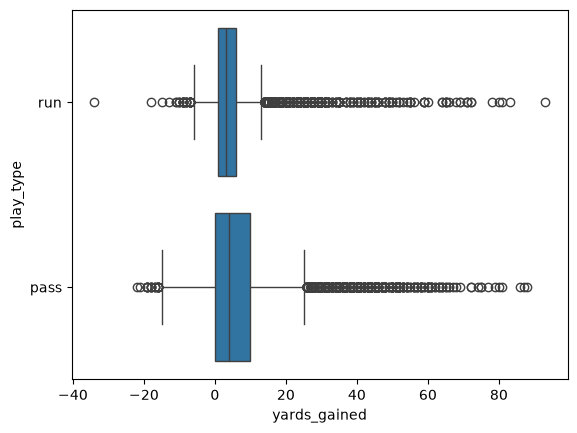

In [20]:
# distribution of run and pass plays by yards gained, the simplest metric
sns.boxplot(data = snspbp, x = "yards_gained", y = "play_type")
plt.show()

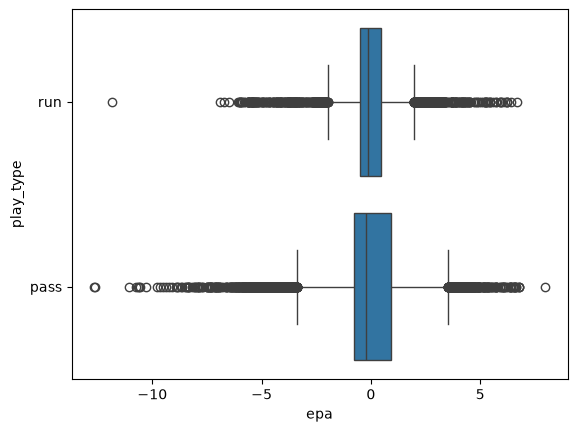

In [23]:
# distribution of run and pass plays by epa/play
sns.boxplot(data = snspbp, x = "epa", y = "play_type")
plt.show()

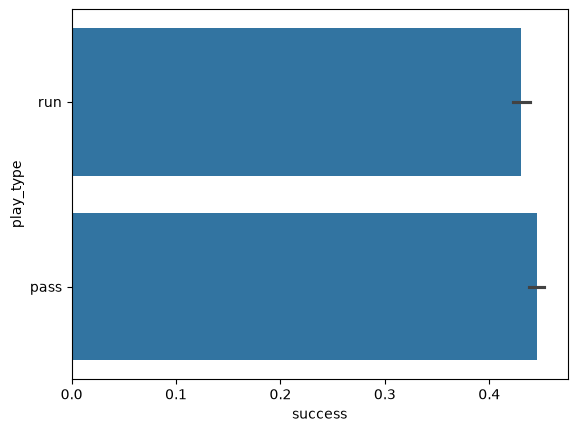

In [28]:
# run and pass plays average success rate
sns.barplot(data = snspbp, x = "success", y = "play_type")
plt.show()

**TODO:** description of the distribution's shape (center, spread, skew, outliers).

# Part 4: Relationships

**TODO (assign):** at least three plots relating two or more features,
chosen with our research questions in mind (scatter plot, subgroup
comparison, time series, correlation matrix). At least one should use the
join/comparison with a secondary dataset (team_stats or the NGS receiving
data) described in README.md.

## Relationship plot 1

In [13]:
# TODO: plot 1 goes here

## Relationship plot 2

In [14]:
# TODO: plot 2 goes here

## Relationship plot 3

In [15]:
# TODO: plot 3 (secondary dataset join/comparison) goes here

# Part 5: So What?

**TODO (assign):** for each relationship plot in Part 4, write a few
sentences on what it shows and why it matters for our research questions.
Was the pattern expected, unexpected, or somewhere in between?

**TODO:** so-what for relationship plot 1.

**TODO:** so-what for relationship plot 2.

**TODO:** so-what for relationship plot 3.

# Part 6: What Next?

**TODO (assign):** for each relationship plot in Part 4, name the question
it points to next (an additional comparison, a subgroup to split out,
another dataset to join, a domain expert to ask). Then restate our research
questions, revised if the data has nudged them, and say what changed and why.

**TODO:** what-next for relationship plot 1.

**TODO:** what-next for relationship plot 2.

**TODO:** what-next for relationship plot 3.

## Revised research questions

**TODO:** restate research questions, note what changed (if anything) and why.